# MAVIS · Project 3, a multimodal RAG assistant

A Retrieval-Augmented Generation assistant whose document base is **centered on video
thumbnails and titles** (the same multimodal pair the whole MAVIS thesis is about),
surrounded by a secondary layer of project documentation in 5 more formats (`md`,
`pdf`, `csv`, `json`, `yaml`, `txt`).

Three ground rules shape the design:

1. **Images and titles are the first-class citizens.** A dedicated video index (SigLIP
   image embeddings + cross-modal text→image + mpnet titles + BM25, fused with RRF,
   the Project-2 engine miniaturized) answers every query with real videos, queryable
   by **text or by image**. Retrieved thumbnails are shown as visual evidence and the
   retrieved titles enter the LLM context.
2. **Everything indexed lives in `corpus/`, and everything in `corpus/` gets indexed.**
   Ingestion scans the folders generically by file extension; dropping a new file into
   `corpus/` adds it to the assistant on the next run. No hardcoded file list.
3. **The folder is self-contained.** 300 videos (320px thumbnails + `videos.csv` with
   their titles and metadata) ship inside `corpus/videos/`; embeddings are computed
   from those local files and cached locally. Nothing references paths outside
   `04-multimodal-rag/`.

| piece | what | where |
|---|---|---|
| core | video index: SigLIP (image, cross-modal) + mpnet (titles) + BM25 + RRF | §3–§4 |
| phase 1 | doc layer: generic ingestion → chunks → mpnet+FAISS + BM25 → RRF → LLM with citations | §5–§10 |
| phase 2 | improvement: cross-encoder re-ranking, measured | §11 |
| evaluation | videos (gold + label-free) · docs (gold) · answers (5 metrics) | §12–§14 |

## 1 · Configuration

The LLM runs behind an **OpenAI-compatible** endpoint (OpenAI, Ollama, LM Studio,
vLLM). Generation is **text-only** by design: the model receives titles and document
chunks; thumbnails are shown to the user as retrieved evidence.

| env var | default | meaning |
|---|---|---|
| `OPENAI_API_KEY` | - | API key (any non-empty string for local servers) |
| `OPENAI_BASE_URL` | `https://api.openai.com/v1` | endpoint |
| `RAG_CHAT_MODEL` | `gpt-5-mini` | generation model |
| `RAG_JUDGE_MODEL` | = chat model | LLM-as-judge model |

Variables can also live in a local `.env` (copy `.env.test`; shell wins over file).
Everything except generation (§10) and answer evaluation (§14) runs without a key.

In [1]:
import os, re, json, time, gc, math, hashlib, unicodedata
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

NB = Path.cwd()  # 04-multimodal-rag/ (self-contained: no parent paths)
CORPUS = NB / "corpus"
VID_DIR = CORPUS / "videos"
CACHE = NB / "cache"
CACHE.mkdir(exist_ok=True)
FIGS = NB / "figures"
FIGS.mkdir(exist_ok=True)

SIGLIP_ID = "google/siglip2-large-patch16-256"  # images + cross-modal (the core)
MPNET_ID = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"  # text↔text
CE_ID = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"  # phase-2 re-ranker

CHUNK_CHARS, CHUNK_OVERLAP = 1800, 200
RRF_K, W_LEX = 60, 1.0
TOPK_CONTEXT, RERANK_POOL, TOPK_VIDEOS = 6, 30, 3


def _load_env(path=None):
    """Minimal .env loader (shell env wins over the file), as in 03-platform."""
    path = path or NB / ".env"
    if path.exists():
        for line in path.read_text().splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))


_load_env()
CHAT_MODEL = os.getenv("RAG_CHAT_MODEL", "gpt-5-mini")
JUDGE_MODEL = os.getenv("RAG_JUDGE_MODEL", CHAT_MODEL)
SEED = 42
rng = np.random.default_rng(SEED)

print("corpus exists :", CORPUS.exists(), "| videos:", VID_DIR.exists())
print(
    "chat model    :",
    CHAT_MODEL,
    "@",
    os.getenv("OPENAI_BASE_URL") or "https://api.openai.com/v1 (default)",
)
print("judge model   :", JUDGE_MODEL)
print("api key set   :", bool(os.getenv("OPENAI_API_KEY")))

corpus exists : True | videos: True
chat model    : gpt-5-mini @ https://api.openai.com/v1 (default)
judge model   : gpt-5-mini
api key set   : True


## 2 · Corpus inventory (index everything in the folders)

No hardcoded file list: this cell walks `corpus/` and reports every file it finds, by
extension. Whatever is in the folders is what gets indexed; the thumbnails feed the
video index (§4) and every other supported extension feeds the document layer (§5).

In [2]:
IMG_EXT = {".jpg", ".jpeg", ".png"}
DOC_EXT = {".md", ".pdf", ".csv", ".json", ".yml", ".yaml", ".txt"}

inventory = defaultdict(list)
for p in sorted(CORPUS.rglob("*")):
    if p.is_file():
        ext = p.suffix.lower()
        if ext in IMG_EXT | DOC_EXT:
            inventory[ext].append(p)

for ext, files in sorted(inventory.items()):
    mb = sum(f.stat().st_size for f in files) / 1e6
    print(f"  {ext:6s}: {len(files):4d} file(s), {mb:7.1f} MB")
n_thumbs = sum(len(v) for e, v in inventory.items() if e in IMG_EXT)
print(f"\nvideo corpus: {n_thumbs} thumbnails + videos.csv (titles & metadata)")
assert (VID_DIR / "videos.csv").exists(), "corpus/videos/videos.csv is required"

  .csv  :    2 file(s),     0.2 MB
  .jpg  :  300 file(s),     5.6 MB
  .json :    1 file(s),     0.1 MB
  .md   :    7 file(s),     0.2 MB
  .pdf  :    5 file(s),    24.9 MB
  .txt  :    2 file(s),     0.0 MB
  .yml  :    1 file(s),     0.0 MB

video corpus: 300 thumbnails + videos.csv (titles & metadata)


## 3 · Encoders (frozen, lazy singletons)

Three frozen encoders, each used where Project 2 measured it is strong:

| encoder | used for | why |
|---|---|---|
| **SigLIP-2 large** (1024-d) | thumbnail embeddings; text→image and image→title cross-modal | shared text/image space, the multimodal core |
| **mpnet multilingual** (768-d) | title↔title and document chunks | SigLIP's text tower is anisotropic at text↔text; mpnet is the measured fix |
| cross-encoder mmarco (§11) | phase-2 re-ranking of doc candidates | reads query+passage together |

In [3]:
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoProcessor, AutoTokenizer


def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def _pool(x):
    return x if torch.is_tensor(x) else x.pooler_output


# ---- SigLIP (images + cross-modal) -----------------------------------------
_SIG = {"m": None, "p": None, "dev": None}


def load_siglip():
    if _SIG["m"] is None:
        t0 = time.time()
        p = AutoProcessor.from_pretrained(SIGLIP_ID)
        m = AutoModel.from_pretrained(SIGLIP_ID).to(get_device()).eval()
        for prm in m.parameters():
            prm.requires_grad_(False)
        _SIG.update(m=m, p=p, dev=get_device())
        print(f"SigLIP loaded on {_SIG['dev']} ({time.time()-t0:.1f}s)")
    return _SIG["m"], _SIG["p"], _SIG["dev"]


@torch.no_grad()
def embed_text_siglip(texts, batch=64):
    m, p, dev = load_siglip()
    out = []
    for s in range(0, len(texts), batch):
        tin = p(
            text=[str(t) for t in texts[s : s + batch]],
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).to(dev)
        out.append(
            F.normalize(_pool(m.get_text_features(**tin)), dim=-1).cpu().float().numpy()
        )
    return np.vstack(out).astype("float32")


@torch.no_grad()
def embed_images_siglip(paths, batch=32, verbose=False):
    m, p, dev = load_siglip()
    out = []
    for s in range(0, len(paths), batch):
        imgs = []
        for pp in paths[s : s + batch]:
            try:
                imgs.append(Image.open(pp).convert("RGB"))
            except Exception:
                imgs.append(Image.new("RGB", (256, 256)))
        pin = p(images=imgs, return_tensors="pt").to(dev)
        out.append(
            F.normalize(_pool(m.get_image_features(**pin)), dim=-1)
            .cpu()
            .float()
            .numpy()
        )
        if verbose:
            print(
                f"  siglip-image {min(s + batch, len(paths))}/{len(paths)}", flush=True
            )
    return np.vstack(out).astype("float32")


def embed_image_siglip(path_or_img):
    img = (
        path_or_img if isinstance(path_or_img, Image.Image) else Image.open(path_or_img)
    )
    m, p, dev = load_siglip()
    with torch.no_grad():
        pin = p(images=[img.convert("RGB")], return_tensors="pt").to(dev)
        return (
            F.normalize(_pool(m.get_image_features(**pin)), dim=-1)
            .cpu()
            .float()
            .numpy()[0]
        )


# ---- mpnet (text↔text) ------------------------------------------------------
_MP = {"m": None, "t": None, "dev": None}


def load_mpnet():
    if _MP["m"] is None:
        t0 = time.time()
        tok = AutoTokenizer.from_pretrained(MPNET_ID)
        m = AutoModel.from_pretrained(MPNET_ID).to(get_device()).eval()
        for prm in m.parameters():
            prm.requires_grad_(False)
        _MP.update(m=m, t=tok, dev=get_device())
        print(f"mpnet loaded on {_MP['dev']} ({time.time()-t0:.1f}s)")
    return _MP["m"], _MP["t"], _MP["dev"]


@torch.no_grad()
def embed_text_mpnet(batch_texts, batch=64, max_length=384, verbose=False):
    """Masked mean-pooling + L2; the recipe Project 2 validated."""
    m, tok, dev = load_mpnet()
    out = []
    for s in range(0, len(batch_texts), batch):
        enc = tok(
            [str(t) for t in batch_texts[s : s + batch]],
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(dev)
        h = m(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        e = (h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        out.append(F.normalize(e, dim=-1).cpu().float().numpy())
        if verbose:
            print(
                f"  mpnet {min(s + batch, len(batch_texts))}/{len(batch_texts)}",
                flush=True,
            )
    return np.vstack(out).astype("float32")


print("encoder helpers ready (models load lazily on first use)")

/Users/hectorpulido/own-projects/MAVIS-Youtube-Video-Optimizer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


encoder helpers ready (models load lazily on first use)


## 4 · The video index (the core)

300 videos, each a **(thumbnail, title, metadata)** triple from `corpus/videos/`. Three
embedding columns are computed **from the local files** and cached (`cache/`,
regenerable; first run encodes everything in a couple of minutes):

| column | encoder | enables |
|---|---|---|
| `VID_THUMB` (1024-d) | SigLIP image | image↔image and text→image search |
| `VID_TSIG` (1024-d) | SigLIP text | image→title cross-modal search |
| `VID_TMP` (768-d) | mpnet | title↔title semantic search |

`search_videos(text=..., image=...)` runs every path the input allows (plus BM25 over
titles for literal matches), fuses them with RRF, and returns ranked videos. This is
Project 2's all-against-all engine, self-contained over the local corpus.

In [4]:
videos = pd.read_csv(VID_DIR / "videos.csv")
videos["thumb_path"] = videos["thumbnail"].map(lambda p: str(VID_DIR / p))
videos = videos[videos["thumb_path"].map(os.path.exists)].reset_index(drop=True)
N_VID = len(videos)
vid_titles = videos["title"].astype(str).tolist()
print(f"video corpus: {N_VID} videos | {videos.channel_handle.nunique()} channels")

VID_CACHE = CACHE / "video_index.npz"
vid_key = hashlib.sha1(
    "\x1e".join(videos["video_id"] + "|" + videos["title"].astype(str)).encode()
).hexdigest()
loaded = False
if VID_CACHE.exists():
    try:
        z = np.load(VID_CACHE, allow_pickle=True)
        if str(z["key"]) == vid_key:
            VID_THUMB, VID_TSIG, VID_TMP = z["thumb"], z["tsig"], z["tmp"]
            loaded = True
            print("video-index cache HIT")
        else:
            print("video-index cache STALE (corpus changed) -> re-encoding")
    except Exception as e:
        print(f"video-index cache UNREADABLE ({e!r}) -> re-encoding")
if not loaded:
    print("video-index cache MISS -> encoding from corpus/videos/ (local files only)")
    VID_THUMB = embed_images_siglip(videos["thumb_path"].tolist(), verbose=True)
    VID_TSIG = embed_text_siglip(vid_titles)
    VID_TMP = embed_text_mpnet(vid_titles)
    np.savez_compressed(
        VID_CACHE, key=np.array(vid_key), thumb=VID_THUMB, tsig=VID_TSIG, tmp=VID_TMP
    )
    print("saved", VID_CACHE.name)
print(
    f"VID_THUMB {VID_THUMB.shape} | VID_TSIG {VID_TSIG.shape} | VID_TMP {VID_TMP.shape}"
)

video corpus: 300 videos | 206 channels
video-index cache MISS -> encoding from corpus/videos/ (local files only)


Loading weights: 100%|██████████| 792/792 [00:00<00:00, 4926.81it/s]


SigLIP loaded on mps (9.9s)
  siglip-image 32/300
  siglip-image 64/300
  siglip-image 96/300
  siglip-image 128/300
  siglip-image 160/300
  siglip-image 192/300
  siglip-image 224/300
  siglip-image 256/300
  siglip-image 288/300
  siglip-image 300/300


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6972.23it/s]


mpnet loaded on mps (4.2s)
saved video_index.npz
VID_THUMB (300, 1024) | VID_TSIG (300, 1024) | VID_TMP (300, 768)


In [5]:
def _lex_tokens(s):
    s = unicodedata.normalize("NFKD", str(s).lower())
    s = "".join(c for c in s if not unicodedata.combining(c))
    return re.findall(r"[a-z0-9]+", s)


def build_bm25(texts_):
    """Okapi BM25 index (k1=1.5, b=0.75) over a list of strings -> scoring closure."""
    docs = [_lex_tokens(t) for t in texts_]
    dl = np.array([len(d) for d in docs], dtype=np.float32)
    avgdl = float(dl.mean()) or 1.0
    inv, dfreq = defaultdict(list), Counter()
    for i, d in enumerate(docs):
        for tok_, f in Counter(d).items():
            inv[tok_].append((i, f))
            dfreq[tok_] += 1
    idf = {t: math.log(1 + (len(docs) - c + 0.5) / (c + 0.5)) for t, c in dfreq.items()}
    K1, B = 1.5, 0.75

    def scores(query):
        sc = np.zeros(len(docs), dtype=np.float32)
        for tok_ in set(_lex_tokens(query)):
            w = idf.get(tok_)
            if w is None:
                continue
            for i, f in inv[tok_]:
                sc[i] += w * f * (K1 + 1) / (f + K1 * (1 - B + B * dl[i] / avgdl))
        return sc

    return scores, len(dfreq)


bm25_vid_scores, vocab_v = build_bm25(vid_titles)
print(f"BM25 over {N_VID} titles | vocab {vocab_v:,}")


def _rrf_order(paths, n, weights=None):
    weights = weights or {}
    fused = np.zeros(n)
    for name, sc in paths.items():
        r = np.empty(n, dtype=int)
        r[np.argsort(-sc)] = np.arange(n)
        fused += weights.get(name, 1.0) / (RRF_K + r + 1)
    return np.argsort(-fused)


VID_PATHS = {
    "mp": "title↔title (mpnet)",
    "xm": "text→thumb (SigLIP)",
    "bm": "title BM25",
    "ii": "thumb↔thumb (SigLIP)",
    "it": "thumb→title (SigLIP)",
}


def video_order(text=None, image=None, use=("mp", "xm", "bm"), w_lex=W_LEX):
    """Full ranking of the video corpus for a text and/or image query."""
    paths, weights = {}, {}
    if text is not None:
        if "mp" in use:
            paths["mp"] = VID_TMP @ embed_text_mpnet([text])[0]
        if "xm" in use:
            paths["xm"] = VID_THUMB @ embed_text_siglip([text])[0]
        if "bm" in use:
            paths["bm"] = bm25_vid_scores(text)
            weights["bm"] = w_lex
    if image is not None:
        q = embed_image_siglip(image)
        paths["ii"] = VID_THUMB @ q
        paths["it"] = VID_TSIG @ q
    assert paths, "provide text and/or image"
    return _rrf_order(paths, N_VID, weights)


def search_videos(text=None, image=None, k=8, use=("mp", "xm", "bm")):
    order = video_order(text, image, use)
    res = videos.iloc[order[:k]][
        ["video_id", "title", "channel_name", "views", "url", "thumb_path"]
    ].copy()
    res.insert(0, "rank", np.arange(1, len(res) + 1))
    return res.reset_index(drop=True)


def show_videos(res, query_label, fname=None, query_img=None):
    n = len(res)
    cols = n + (1 if query_img is not None else 0)
    fig, axes = plt.subplots(1, cols, figsize=(2.6 * cols, 2.6))
    axes = np.atleast_1d(axes)
    off = 0
    if query_img is not None:
        axes[0].imshow(Image.open(query_img))
        axes[0].set_title("QUERY image", fontsize=8)
        axes[0].axis("off")
        off = 1
    for i, r in enumerate(res.itertuples()):
        ax = axes[i + off]
        ax.imshow(Image.open(r.thumb_path))
        ax.set_title(f"#{r.rank} · {str(r.title)[:34]}", fontsize=6.5)
        ax.axis("off")
    fig.suptitle(query_label, fontsize=9)
    plt.tight_layout()
    if fname:
        plt.savefig(FIGS / fname, dpi=130)
    plt.show()

BM25 over 300 titles | vocab 1,675


TEXT QUERY: 'recetas de cocina fáciles'


,rank,title,channel_name,views
0,1,"Pan Turco Sin Horno!!queda tierno, suave y Del...",LA COCINA Y SU SABOR,81290
1,2,MEJORES TENDENCIAS de DECORACIÓN para tu COCIN...,Decoración con Estilo,9217
2,3,FOOD PROCESSING SIMULATOR - GAMEPLAY PC (4K 60...,MxPlay,156
3,4,Nadie imagina lo rica que queda esta ensalada ...,Q'Rico recetas,13240
4,5,La Carne en Tarro Olvidada de la Segunda Guerr...,Cocina de Supervivencia,810


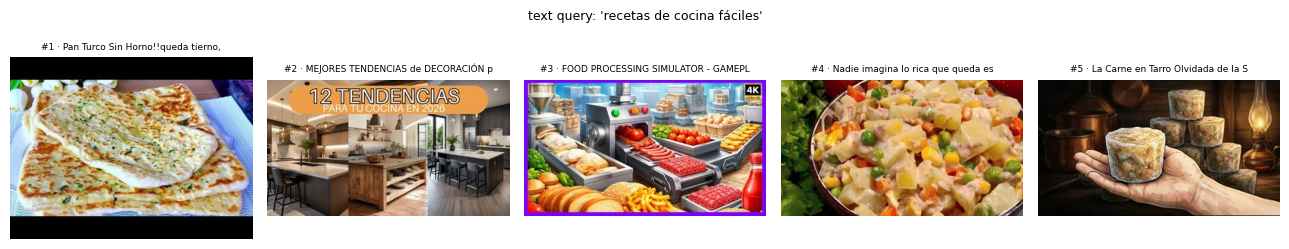

TEXT QUERY: 'agentes de inteligencia artificial en local'


,rank,title,channel_name,views
0,1,LOS TESOROS DE DAVE - CAZADORES DE TESOROS,History Latinoamérica,4166
1,2,Cómo conseguir Cuarzo en StarRupture 💎 Dónde e...,El Holandes Errante,75
2,3,Una nueva oportunidad de Civislend en Marbella,esRadio,206
3,4,Tencent's Covo-Audio: Local Install & Demo of ...,Fahd Mirza,3142
4,5,INTERCAMBIADOS (2026) RESUMEN EN MINUTOS,ENMINUTOS,788437


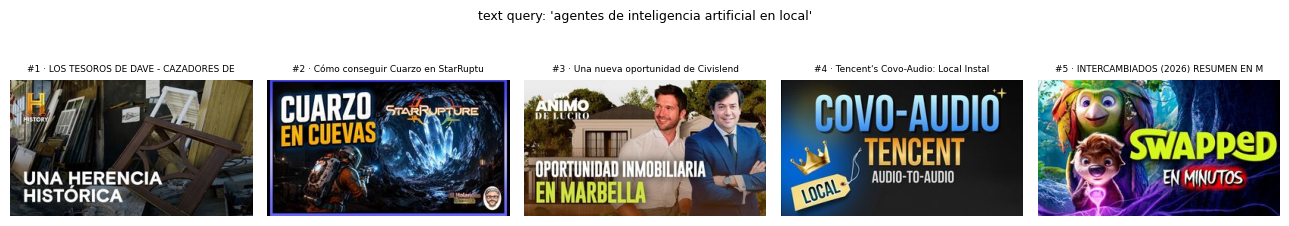

IMAGE QUERY: thumbnail of '¿Por qué sigo varada en Dubai?'


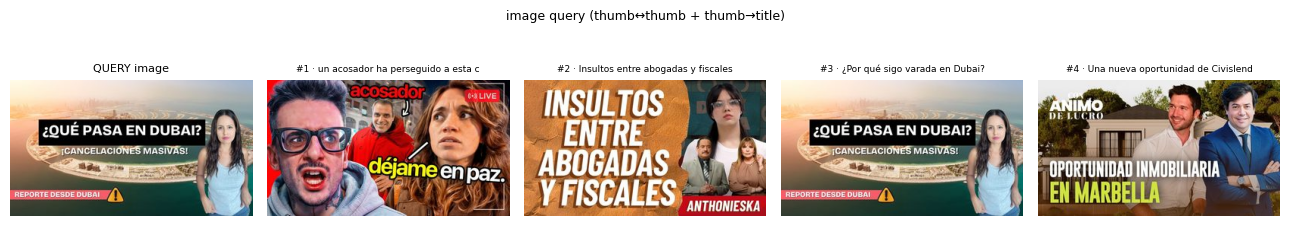

In [6]:
# --- demos: text queries (Spanish) against thumbnails+titles ----------------
for i, q in enumerate(
    ["recetas de cocina fáciles", "agentes de inteligencia artificial en local"]
):
    res = search_videos(text=q, k=5)
    print("=" * 90, f"\nTEXT QUERY: {q!r}")
    display(res[["rank", "title", "channel_name", "views"]])
    show_videos(res, f"text query: {q!r}", fname=f"video_search_text_{i}.png")

# --- demo: IMAGE as the query (find videos that look like this) -------------
probe = videos.iloc[int(rng.integers(N_VID))]
res = search_videos(image=probe["thumb_path"], k=4, use=())
print("=" * 90, f"\nIMAGE QUERY: thumbnail of {probe['title']!r}")
show_videos(
    res,
    "image query (thumb↔thumb + thumb→title)",
    fname="video_search_image.png",
    query_img=probe["thumb_path"],
)

## 5 · Document layer: generic ingestion by extension

One loader per **extension**, applied to every matching file the inventory found
(thumbnails excluded: they belong to the video index). Structured formats are
*serialized into sentences* before indexing, generically:

- **csv**: a summary unit (file, row count, columns, first rows) plus every row as
  `column: value` sentences, in groups. Works for any CSV dropped into the corpus.
- **json**: a summary of the top-level structure plus one unit per entry (scalar
  fields verbatim, nested lists/objects abbreviated to their size).
- **yaml**: the tree flattened to dotted `key: value` lines, plus the raw text.
- **md**: split by headings; **pdf**: one unit per page (`pypdf`); **txt**: paragraph
  blocks.

In [7]:
def _read(p):
    return Path(p).read_text(encoding="utf-8", errors="ignore")


def load_md(path):
    units, sec, buf = [], "intro", []
    for line in _read(path).splitlines():
        m = re.match(r"^(#{1,3})\s+(.*)", line)
        if m:
            if "\n".join(buf).strip():
                units.append((sec, "\n".join(buf).strip()))
            sec, buf = m.group(2).strip(), []
        else:
            buf.append(line)
    if "\n".join(buf).strip():
        units.append((sec, "\n".join(buf).strip()))
    return units


def load_pdf(path):
    from pypdf import PdfReader

    units = []
    for i, page in enumerate(PdfReader(path).pages):
        t = re.sub(r"[ \t]+", " ", (page.extract_text() or "")).strip()
        if len(t) > 80:
            units.append((f"page {i+1}", t))
    return units


def load_csv(path):
    df = pd.read_csv(path)

    def row_text(tup):
        return "; ".join(f"{c}: {v}" for c, v in zip(df.columns, tup) if pd.notna(v))

    rows = [row_text(t) for t in df.itertuples(index=False, name=None)]
    units = [
        (
            "summary",
            f"CSV file {Path(path).name}: {len(df)} rows. Columns: "
            f"{', '.join(df.columns)}. First rows: " + " | ".join(rows[:3]),
        )
    ]
    G = 10
    for s in range(0, len(rows), G):
        units.append((f"rows {s+1}-{min(s+G, len(rows))}", "\n".join(rows[s : s + G])))
    return units


def load_json(path):
    data = json.loads(_read(path))

    def brief(v):
        if isinstance(v, dict):
            return "{" + ", ".join(list(v)[:8]) + "}"
        if isinstance(v, list):
            return f"[{len(v)} items]"
        return str(v)

    if isinstance(data, list):
        entries, head = data, f"list of {len(data)} entries"
    elif isinstance(data, dict) and any(isinstance(v, list) for v in data.values()):
        key = next(k for k, v in data.items() if isinstance(v, list))
        entries, head = (
            data[key],
            f"object with keys {', '.join(data)}; '{key}' holds {len(data[key])} entries",
        )
    else:
        entries, head = [data], "single object"
    units = [("summary", f"JSON file {Path(path).name}: {head}.")]
    lines = [
        "; ".join(f"{k}: {brief(v)}" for k, v in e.items())
        if isinstance(e, dict)
        else str(e)
        for e in entries
    ]
    G = 5
    for s in range(0, len(lines), G):
        units.append(
            (f"entries {s+1}-{min(s+G, len(lines))}", "\n".join(lines[s : s + G]))
        )
    return units


def load_yaml(path):
    import yaml

    raw = _read(path)
    lines = []

    def walk(node, prefix=""):
        if isinstance(node, dict):
            for k, v in node.items():
                walk(v, f"{prefix}{k}.")
        elif isinstance(node, list):
            lines.append(f"{prefix[:-1]}: " + "; ".join(str(x) for x in node[:12]))
        else:
            lines.append(f"{prefix[:-1]}: {node}")

    walk(yaml.safe_load(raw))
    return [
        (
            "structure",
            f"YAML file {Path(path).name}, flattened keys:\n" + "\n".join(lines),
        ),
        ("raw", raw),
    ]


def load_txt(path):
    blocks = [b.strip() for b in re.split(r"\n\s*\n", _read(path)) if b.strip()]
    return [(f"block {i+1}", b) for i, b in enumerate(blocks)]


LOADERS = {
    ".md": load_md,
    ".pdf": load_pdf,
    ".csv": load_csv,
    ".json": load_json,
    ".yml": load_yaml,
    ".yaml": load_yaml,
    ".txt": load_txt,
}

documents = []
for ext, files in sorted(inventory.items()):
    if ext not in LOADERS:
        continue  # images are the video index's job (§4)
    for p in files:
        doc_id = str(p.relative_to(CORPUS))
        fmt = {"yml": "yaml", "jpeg": "jpg"}.get(ext.lstrip("."), ext.lstrip("."))
        documents.append((doc_id, fmt, LOADERS[ext](p)))

per_fmt = Counter(f for _, f, _ in documents)
print(
    f"documents: {len(documents)} | semantic units: {sum(len(u) for *_, u in documents)}"
)
for f, c in sorted(per_fmt.items()):
    u = sum(len(un) for _, ff, un in documents if ff == f)
    print(f"  {f:5s}: {c:2d} docs, {u:4d} units")

documents: 18 | semantic units: 369
  csv  :  2 docs,  117 units
  json :  1 docs,    5 units
  md   :  7 docs,  174 units
  pdf  :  5 docs,   55 units
  txt  :  2 docs,   16 units
  yaml :  1 docs,    2 units


## 6 · Chunking the document layer

Greedy packing of consecutive units of the same document up to ~1800 characters
(≈450 tokens), 200-char overlap when a unit must be hard-split. Every chunk carries a
provenance header `[doc_id · section]`: it makes citations checkable, lets BM25 match
file names literally, and gives the embedding document context.

chunks: 585 | median size: 1792 chars


,docs,chunks,mean_chars
format,,,
csv,2,256,1408.0
json,1,1,1552.0
md,7,129,1405.0
pdf,5,193,1575.0
txt,2,4,1136.0
yaml,1,2,1088.0


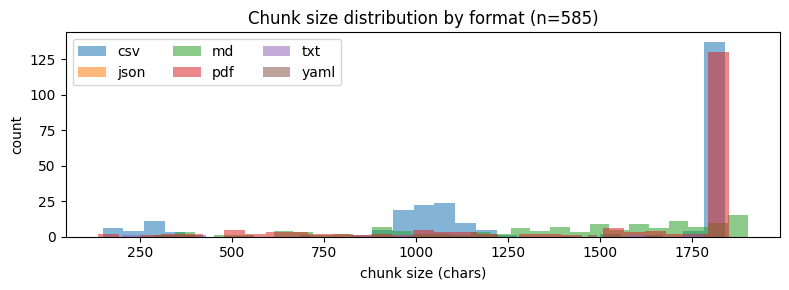

In [8]:
def _split_long(text, max_chars=CHUNK_CHARS, overlap=CHUNK_OVERLAP):
    out, buf = [], ""
    for p in re.split(r"\n\s*\n", text):
        if len(p) > max_chars:
            if buf:
                out.append(buf)
                buf = ""
            s = 0
            while s < len(p):
                out.append(p[s : s + max_chars])
                s += max_chars - overlap
        elif len(buf) + len(p) + 2 <= max_chars:
            buf = (buf + "\n\n" + p) if buf else p
        else:
            out.append(buf)
            buf = (buf[-overlap:] + "\n\n" + p) if overlap else p
    if buf:
        out.append(buf)
    return [x for x in out if x.strip()]


def make_chunks(doc_id, fmt, units):
    out, secs, parts, cur = [], [], [], 0

    def flush():
        nonlocal secs, parts, cur
        if parts:
            sec = secs[0] + (" (+)" if len(set(secs)) > 1 else "")
            out.append(
                {
                    "doc_id": doc_id,
                    "format": fmt,
                    "section": sec,
                    "body": "\n\n".join(parts),
                }
            )
        secs, parts, cur = [], [], 0

    for sec, text in units:
        for piece in _split_long(text) if len(text) > CHUNK_CHARS else [text]:
            if cur + len(piece) > CHUNK_CHARS and cur > 0:
                flush()
            secs.append(sec)
            parts.append(piece)
            cur += len(piece) + 2
    flush()
    return out


chunks = []
for doc_id, fmt, units in documents:
    chunks.extend(make_chunks(doc_id, fmt, units))
chunks_df = pd.DataFrame(chunks)
chunks_df["text"] = (
    "[" + chunks_df["doc_id"] + " · " + chunks_df["section"] + "]\n" + chunks_df["body"]
)
chunks_df["n_chars"] = chunks_df["text"].str.len()
texts = chunks_df["text"].tolist()
doc_of_chunk = chunks_df["doc_id"].to_numpy()
N_CHUNKS = len(chunks_df)

print(f"chunks: {N_CHUNKS} | median size: {int(chunks_df.n_chars.median())} chars")
display(
    chunks_df.groupby("format")
    .agg(
        docs=("doc_id", "nunique"),
        chunks=("text", "count"),
        mean_chars=("n_chars", "mean"),
    )
    .round(0)
)

fig, ax = plt.subplots(figsize=(8, 3))
for f, sub in chunks_df.groupby("format"):
    ax.hist(sub["n_chars"], bins=30, alpha=0.55, label=f)
ax.set_xlabel("chunk size (chars)")
ax.set_ylabel("count")
ax.legend(ncol=3)
ax.set_title(f"Chunk size distribution by format (n={N_CHUNKS})")
plt.tight_layout()
plt.savefig(FIGS / "chunk_sizes.png", dpi=130)
plt.show()

## 7 · Document embeddings + vector store

mpnet over the chunks (cached, keyed by a corpus hash) in a **FAISS `IndexFlatIP`**:
exact inner product, which on L2-normalized vectors is cosine. The sanity cell
measures what Project 2 argued: at this scale the flat index and a NumPy dot product
return the identical top-10 at comparable latency; an approximate index (IVF/HNSW)
would trade recall for speed this corpus does not need.

In [9]:
import faiss

EMB_CACHE = CACHE / "chunk_emb_mpnet.npz"
corpus_key = hashlib.sha1("\x1e".join(texts).encode()).hexdigest()
EMB = None
if EMB_CACHE.exists():
    try:
        z = np.load(EMB_CACHE, allow_pickle=True)
        if str(z["key"]) == corpus_key and str(z["model"]) == MPNET_ID:
            EMB = z["emb"].astype("float32")
            print(f"chunk-embedding cache HIT: {EMB.shape}")
        else:
            print("chunk-embedding cache STALE -> re-encoding")
    except Exception as e:
        print(f"chunk-embedding cache UNREADABLE ({e!r}) -> re-encoding")
if EMB is None:
    print("cache MISS -> encoding chunks")
    EMB = embed_text_mpnet(texts, verbose=True)
    np.savez_compressed(
        EMB_CACHE, emb=EMB, key=np.array(corpus_key), model=np.array(MPNET_ID)
    )
D = EMB.shape[1]

INDEX = faiss.IndexFlatIP(D)
INDEX.add(EMB)
print(f"FAISS IndexFlatIP: {INDEX.ntotal} vectors x {D}d")


def dense_scores(q_emb):
    Ds, Is = INDEX.search(q_emb[None].astype("float32"), N_CHUNKS)
    s = np.empty(N_CHUNKS, dtype="float32")
    s[Is[0]] = Ds[0]
    return s


probe_i = rng.choice(N_CHUNKS, 50, replace=False)
overlap, t_np, t_fa = [], 0.0, 0.0
for i in probe_i:
    q = EMB[i]
    t0 = time.perf_counter()
    s_np = EMB @ q
    t_np += time.perf_counter() - t0
    t0 = time.perf_counter()
    s_fa = dense_scores(q)
    t_fa += time.perf_counter() - t0
    overlap.append(len(set(np.argsort(-s_np)[:10]) & set(np.argsort(-s_fa)[:10])) / 10)
print(f"top-10 overlap FAISS vs NumPy: {np.mean(overlap):.3f}")
print(f"mean latency/query  numpy: {1e3*t_np/50:.2f} ms | faiss: {1e3*t_fa/50:.2f} ms")

cache MISS -> encoding chunks
  mpnet 64/585
  mpnet 128/585
  mpnet 192/585
  mpnet 256/585
  mpnet 320/585
  mpnet 384/585
  mpnet 448/585
  mpnet 512/585
  mpnet 576/585
  mpnet 585/585
FAISS IndexFlatIP: 585 vectors x 768d
top-10 overlap FAISS vs NumPy: 1.000
mean latency/query  numpy: 0.02 ms | faiss: 1.15 ms


## 8 · Lexical layer for documents (BM25)

The same `build_bm25` used for titles, now over chunks. It covers what dense retrieval
structurally misses: literal identifiers (`mavis_hf_cache`, `KNN_TEMPS`,
`ytInitialData`) that in this corpus are often exactly what a question asks about.

In [10]:
bm25_scores, vocab_d = build_bm25(texts)
print(f"BM25 over {N_CHUNKS} chunks | vocab {vocab_d:,}")

BM25 over 585 chunks | vocab 17,173


## 9 · Hybrid document retrieval (dense + BM25, RRF)

`retrieve()` is the single entry point used by the assistant and by the evaluation
(`mode ∈ {dense, lexical, hybrid}`; `rerank=True` switches phase 2 on).

In [11]:
def retrieve(query, k=TOPK_CONTEXT, mode="hybrid", rerank=False, pool=RERANK_POOL):
    paths, weights = {}, {}
    if mode in ("dense", "hybrid"):
        paths["dense"] = dense_scores(embed_text_mpnet([query])[0])
    if mode in ("lexical", "hybrid"):
        paths["bm25"] = bm25_scores(query)
        weights["bm25"] = W_LEX
    order = _rrf_order(paths, N_CHUNKS, weights)
    if rerank:
        order = np.concatenate([ce_rerank(query, order[:pool]), order[pool:]])
    res = chunks_df.iloc[order[:k]][["doc_id", "format", "section", "body"]].copy()
    res.insert(0, "rank", np.arange(1, len(res) + 1))
    return res.reset_index(drop=True), order


for q in [
    "¿Por qué el buscador usa dos encoders distintos?",
    "¿Qué canal tiene más vídeos en el corpus completo de MAVIS?",
]:
    res, _ = retrieve(q, k=4)
    print("=" * 90, f"\nQUERY: {q!r}")
    display(res[["rank", "doc_id", "format", "section"]])

QUERY: '¿Por qué el buscador usa dos encoders distintos?'


,rank,doc_id,format,section
0,1,md/papers-sintesis.md,md,2.1. El techo del contenido puro (la convergen...
1,2,md/root-README.md,md,10 · Glossary (+)
2,3,md/papers-sintesis.md,md,4. Advertencias metodológicas para la redacció...
3,4,md/02-retrieval-README.md,md,Search & encoders


QUERY: '¿Qué canal tiene más vídeos en el corpus completo de MAVIS?'


,rank,doc_id,format,section
0,1,csv/channel_stats.csv,csv,rows 661-670
1,2,videos/videos.csv,csv,rows 51-60
2,3,md/papers-sintesis.md,md,Síntesis de literatura — MAVIS
3,4,csv/channel_stats.csv,csv,rows 471-480


## 10 · Generation: the assistant (text-only LLM, visual evidence)

The context the LLM receives has two parts: the top-6 document chunks as numbered
blocks, and a block labeled **[V]** with the videos most related to the question
(title, channel, views) coming from the §4 index. Generation is text-only by design;
the retrieved **thumbnails are displayed to the user** as visual evidence next to the
answer. The system prompt forces the four behaviors §14 measures: context-only
answers, inline citations, the question's language, and explicit abstention.

In [12]:
import openai
from openai import OpenAI

_client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY") or "not-set", timeout=120.0, max_retries=2
)

# Reasoning models (gpt-5*, o*) reject `temperature` and want `max_completion_tokens`;
# classic ones (gpt-4o*, local servers) use `temperature` + `max_tokens`. The style is
# sniffed on the first BadRequest and remembered per model.
_PARAM_STYLE = {}


def _chat(model, system, user, max_tokens=600):
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]

    def _call(style):
        if style == "classic":
            return _client.chat.completions.create(
                model=model, messages=messages, temperature=0, max_tokens=max_tokens
            )
        return _client.chat.completions.create(
            model=model,
            messages=messages,
            max_completion_tokens=max(4 * max_tokens, 2000),
        )

    style = _PARAM_STYLE.get(model, "classic")
    try:
        r = _call(style)
    except openai.BadRequestError:
        style = "reasoning" if style == "classic" else "classic"
        r = _call(style)
    _PARAM_STYLE[model] = style
    return (r.choices[0].message.content or "").strip()


try:
    _chat(
        CHAT_MODEL,
        "You are a ping service.",
        "Reply with the single word: pong",
        max_tokens=4,
    )
    LLM_OK, LLM_MSG = True, "ok"
except Exception as e:
    LLM_OK, LLM_MSG = False, f"{type(e).__name__}: {str(e)[:160]}"
print(f"LLM available: {LLM_OK}  ({LLM_MSG})")
if not LLM_OK:
    print(
        "-> generation sections will skip; set OPENAI_API_KEY (or .env) and re-run from here."
    )

LLM available: True  (ok)


Q: ¿Qué es 'el muro' en MAVIS y cómo se rompió?

El "muro" en MAVIS es el techo conocido de predicción de popularidad usando solo señales de contenido (sin reputación de canal ni señales sociales), aproximadamente Spearman ≈ 0.23–0.28 [2][5].  
Se "rompió" en trabajos como Cui et al. que reportan r = 0.73, pero ese número incluye controles como suscriptores, duración y categoría —es decir, se supera el muro añadiendo reputación/contexto, no mejorando la señal de contenido puro [2][5].  
MAVIS trata el muro como un resultado caracterizado: neutraliza el confound de canal (log z‑score por canal) y evalúa en el espacio normalizado en vez de views absolutas, siguiendo la evidencia de la literatura [2][5].

  [retrieval 4960 ms | generation 12.7 s]


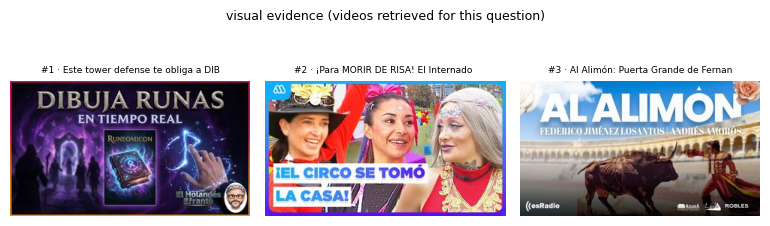

Q: ¿Qué vídeos del corpus hablan de agentes de IA o modelos en local?

El vídeo "Tencent's Covo-Audio: Local Install & Demo of a 7B End-to-End Voice AI Model" trata de instalación local y un modelo de voz de 7B → es relevante [V].  
Los otros dos vídeos listados ("LOS TESOROS DE DAVE - CAZADORES DE TESOROS" y "Insultos entre abogadas y fiscales…") no tratan sobre agentes de IA ni modelos en local [V].

  [retrieval 2031 ms | generation 7.1 s]


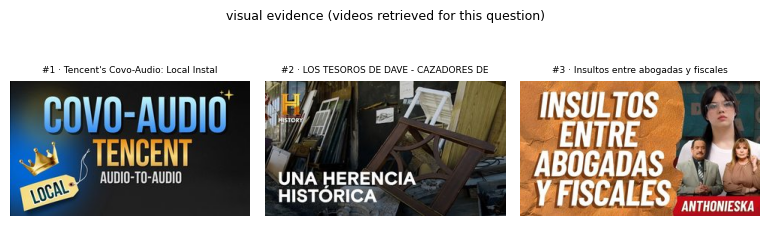

In [13]:
SYSTEM_PROMPT = (
    "You are the assistant for MAVIS, a master's thesis project about predicting and "
    "searching YouTube videos. You answer questions using ONLY the numbered context "
    "blocks provided.\n"
    "Rules:\n"
    "1. Use only information present in the context blocks. Never use outside knowledge.\n"
    "2. After each claim, cite the supporting block(s) inline like [1] or [2][3]. The "
    "block labeled [V] lists corpus videos related to the question; cite it as [V] when you use it.\n"
    "3. Answer in the same language as the question.\n"
    "4. If the context does not contain the answer, say explicitly (in the question's "
    "language) that the MAVIS documentation does not cover it. Do not guess.\n"
    "5. Be concise: 2-5 sentences."
)


def build_context(res):
    return "\n\n".join(
        f"[{r.rank}] ({r.doc_id} · {r.section})\n{r.body}" for r in res.itertuples()
    )


def build_video_block(vids):
    lines = [
        f'- "{r.title}" | channel: {r.channel_name} | {int(r.views):,} views'
        for r in vids.itertuples()
    ]
    return (
        "[V] Videos from the local corpus most related to the question:\n"
        + "\n".join(lines)
    )


def rag_answer(
    question, mode="hybrid", rerank=False, k=TOPK_CONTEXT, n_videos=TOPK_VIDEOS
):
    t0 = time.perf_counter()
    res, _ = retrieve(question, k=k, mode=mode, rerank=rerank)
    vids = search_videos(text=question, k=n_videos)
    t_ret = time.perf_counter() - t0
    ctx = build_context(res) + "\n\n" + build_video_block(vids)
    t0 = time.perf_counter()
    ans = _chat(
        CHAT_MODEL, SYSTEM_PROMPT, "Context:\n\n" + ctx + "\n\nQuestion: " + question
    )
    return {
        "answer": ans,
        "chunks": res,
        "videos": vids,
        "context": ctx,
        "t_retrieval": t_ret,
        "t_generation": time.perf_counter() - t0,
    }


if LLM_OK:
    for q in [
        "¿Qué es 'el muro' en MAVIS y cómo se rompió?",
        "¿Qué vídeos del corpus hablan de agentes de IA o modelos en local?",
    ]:
        out = rag_answer(q)
        print("=" * 90, f"\nQ: {q}\n")
        print(out["answer"])
        print(
            f"\n  [retrieval {out['t_retrieval']*1e3:.0f} ms | generation {out['t_generation']:.1f} s]"
        )
        show_videos(
            out["videos"], "visual evidence (videos retrieved for this question)"
        )
else:
    print("skipped (no LLM); see §10 prerequisites")

## 11 · Phase 2, the improvement: cross-encoder re-ranking

The step Project 2 proposed and left pending, implemented and measured here. A
bi-encoder embeds query and chunk *independently*: fast, and limited to comparing what
survives compression into one vector. A **cross-encoder**
(`mmarco-mMiniLMv2-L12-H384-v1`, multilingual, trained on mMARCO relevance) reads both
together with full attention and scores relevance directly: sharp and slow. It runs
only on the **top-30 candidates** of the hybrid stage; §13 and §14 measure whether the
ranking gain justifies the latency.

In [14]:
from transformers import AutoModelForSequenceClassification

_CE = {"m": None, "t": None, "dev": None}


def load_ce():
    if _CE["m"] is None:
        t0 = time.time()
        tok = AutoTokenizer.from_pretrained(CE_ID)
        m = (
            AutoModelForSequenceClassification.from_pretrained(CE_ID)
            .to(get_device())
            .eval()
        )
        for prm in m.parameters():
            prm.requires_grad_(False)
        _CE.update(m=m, t=tok, dev=get_device())
        print(f"cross-encoder loaded on {_CE['dev']} ({time.time()-t0:.1f}s)")
    return _CE["m"], _CE["t"], _CE["dev"]


@torch.no_grad()
def ce_scores(query, cand_texts, batch=16):
    m, tok, dev = load_ce()
    out = []
    for s in range(0, len(cand_texts), batch):
        cb = cand_texts[s : s + batch]
        enc = tok(
            [query] * len(cb),
            cb,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt",
        ).to(dev)
        out.append(m(**enc).logits.squeeze(-1).float().cpu().numpy())
    return np.concatenate(out)


def ce_rerank(query, idxs):
    idxs = np.asarray(idxs)
    return idxs[np.argsort(-ce_scores(query, [texts[i] for i in idxs]))]


q_demo = "¿Qué efecto encuentra Cui et al. para la coherencia título-thumbnail?"
before, _ = retrieve(q_demo, k=5, rerank=False)
after, _ = retrieve(q_demo, k=5, rerank=True)
print(f"QUERY: {q_demo!r}\n--- hybrid (before) ---")
display(before[["rank", "doc_id", "section"]])
print("--- hybrid + cross-encoder (after) ---")
display(after[["rank", "doc_id", "section"]])

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7404.96it/s]


cross-encoder loaded on mps (4.7s)
QUERY: '¿Qué efecto encuentra Cui et al. para la coherencia título-thumbnail?'
--- hybrid (before) ---


,rank,doc_id,section
0,1,md/papers-sintesis.md,4. Advertencias metodológicas para la redacció...
1,2,md/papers-sintesis.md,3. Implicaciones concretas para el TFM
2,3,pdf/1-s2.0-S0148296324003539-main.pdf,page 3
3,4,md/papers-sintesis.md,TL;DR (lo esencial en 6 puntos) (+)
4,5,md/papers-sintesis.md,"1.1. Cui, Chung, Peng & Wang (2024) — *Clicks ..."


--- hybrid + cross-encoder (after) ---


,rank,doc_id,section
0,1,md/papers-sintesis.md,TL;DR (lo esencial en 6 puntos)
1,2,pdf/1-s2.0-S0148296324003539-main.pdf,page 1
2,3,pdf/1-s2.0-S0148296324003539-main.pdf,page 2
3,4,md/papers-sintesis.md,"1.1. Cui, Chung, Peng & Wang (2024) — *Clicks ..."
4,5,pdf/1-s2.0-S0148296324003539-main.pdf,page 3


## 12 · Evaluation I, the video index (the core)

Two complementary measurements, following Project 2's playbook:

**a) Label-free cross-modal alignment.** Each title (SigLIP text) queries all 300
thumbnails; the rank of its *own* thumbnail measures the text→image alignment with no
manual labels (random Recall@1 = 1/300 ≈ 0.003).

**b) Hand-annotated gold set.** [`eval_videos.json`](eval_videos.json): 10 Spanish
queries with 79 relevant videos annotated by reading the 300 titles. The ablation
compares what each path adds: mpnet titles alone, + cross-modal text→thumbnail,
+ BM25 (the full hybrid). Metrics over the *video* ranking: Recall@5/@10 (fraction of
the query's relevant videos found), MRR, nDCG@10, Precision@5, latency. Limitations:
one annotator, binary relevance, n=10 queries (indicative only).

In [15]:
# a) label-free: title (SigLIP text) -> own thumbnail, all-against-all
sims = VID_TSIG @ VID_THUMB.T
true = np.diag(sims)
rank = (sims > true[:, None]).sum(axis=1)
print(f"--- cross-modal self-retrieval (N={N_VID}) ---")
for k in (1, 5, 10):
    print(f"  Recall@{k:<2}: {(rank < k).mean():.3f}   (random ≈ {k/N_VID:.3f})")
print(f"  MRR      : {(1.0/(rank+1)).mean():.3f}")

--- cross-modal self-retrieval (N=300) ---
  Recall@1 : 0.203   (random ≈ 0.003)
  Recall@5 : 0.323   (random ≈ 0.017)
  Recall@10: 0.390   (random ≈ 0.033)
  MRR      : 0.269


video gold set: 10 queries, 79 relevant
  mpnet titles     done
  + cross-modal    done
  cross-modal only done
  hybrid (full)    done

=== Video retrieval (10 queries, 79 relevant videos) ===


,R@5,R@10,MRR,nDCG@10,P@5,ms
mpnet titles,0.470,0.666,0.920,0.716,0.72,49.0
+ cross-modal,0.424,0.645,0.783,0.647,0.60,46.0
cross-modal only,0.291,0.382,0.548,0.380,0.36,26.0
hybrid (full),0.220,0.394,0.724,0.407,0.36,38.0


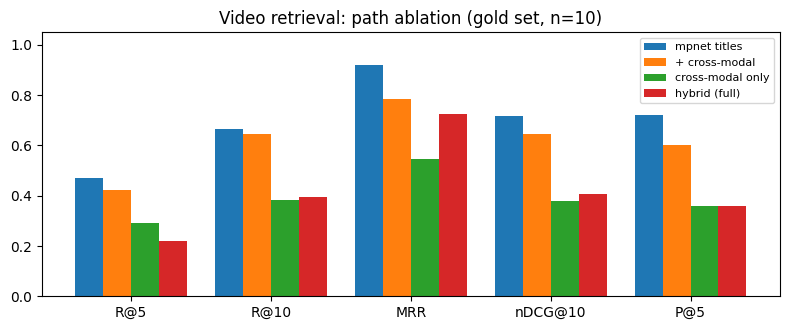

In [16]:
VGOLD = json.loads((NB / "eval_videos.json").read_text(encoding="utf-8"))["queries"]
vid_pos = {v: i for i, v in enumerate(videos["video_id"])}
print(
    f"video gold set: {len(VGOLD)} queries, {sum(q['n_relevant'] for q in VGOLD)} relevant"
)


def eval_videos_cfg(use):
    rows = []
    for q in VGOLD:
        gold = {vid_pos[v] for v in q["relevant_video_ids"] if v in vid_pos}
        t0 = time.perf_counter()
        order = video_order(text=q["query"], use=use)
        dt = time.perf_counter() - t0
        rel = np.isin(order, list(gold))
        first = int(np.argmax(rel)) if rel.any() else None
        dcg = sum(1.0 / math.log2(i + 2) for i, r in enumerate(rel[:10]) if r)
        idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(gold), 10)))
        rows.append(
            {
                "id": q["id"],
                "R@5": rel[:5].sum() / len(gold),
                "R@10": rel[:10].sum() / len(gold),
                "MRR": 0.0 if first is None else 1.0 / (first + 1),
                "nDCG@10": dcg / idcg,
                "P@5": float(rel[:5].mean()),
                "ms": dt * 1e3,
            }
        )
    return pd.DataFrame(rows)


VID_CONFIGS = {
    "mpnet titles": ("mp",),
    "+ cross-modal": ("mp", "xm"),
    "cross-modal only": ("xm",),
    "hybrid (full)": ("mp", "xm", "bm"),
}
video_order(text="calentamiento", use=("mp", "xm", "bm"))  # warm encoders before timing
vid_res = {}
for name, use in VID_CONFIGS.items():
    vid_res[name] = eval_videos_cfg(use)
    print(f"  {name:16s} done", flush=True)

VID_TABLE = pd.DataFrame(
    {
        n: df[["R@5", "R@10", "MRR", "nDCG@10", "P@5", "ms"]].mean()
        for n, df in vid_res.items()
    }
).T.round(3)
VID_TABLE["ms"] = VID_TABLE["ms"].round(0)
print("\n=== Video retrieval (10 queries, 79 relevant videos) ===")
display(VID_TABLE)
(CACHE / "video_eval.json").write_text(VID_TABLE.to_json(indent=2))

fig, ax = plt.subplots(figsize=(8, 3.4))
metrics = ["R@5", "R@10", "MRR", "nDCG@10", "P@5"]
x = np.arange(len(metrics))
w = 0.2
for j, name in enumerate(VID_CONFIGS):
    ax.bar(x + (j - 1.5) * w, VID_TABLE.loc[name, metrics], w, label=name)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.set_title("Video retrieval: path ablation (gold set, n=10)")
plt.tight_layout()
plt.savefig(FIGS / "video_retrieval_metrics.png", dpi=130)
plt.show()

## 13 · Evaluation II, the document layer

[`eval_qa.json`](eval_qa.json): 27 answerable questions (relevant documents + reference
answers annotated from the sources, before running the system) plus 4 unanswerable ones
for §14. Spanish questions over a mostly-English corpus, on purpose. Annotation is at
**document** level (stable across re-chunking); a chunk is relevant iff it belongs to a
gold document. Metrics: Recall@5/@10 (gold-doc coverage), MRR (first relevant chunk),
nDCG@10 (one gain per gold doc, at first occurrence), Precision@5 (≈ context
precision), latency. Configurations: dense, hybrid, hybrid+rerank (phase 2).

doc gold set: 27 answerable + 4 unanswerable
  dense          done in 1.1s
  hybrid         done in 0.4s
  hybrid+rerank  done in 14.8s

=== Document retrieval (27 queries, doc-level relevance) ===


,R@5,R@10,MRR,nDCG@10,P@5,ms
dense,0.704,0.778,0.520,0.544,0.304,39.0
hybrid,0.500,0.741,0.441,0.487,0.289,15.0
hybrid+rerank,0.815,0.889,0.811,0.786,0.519,547.0


=== MRR by primary gold format ===


,dense,hybrid,hybrid+rerank,n
format,,,,
csv,0.583,0.833,0.456,3
json,0.004,0.077,1.000,1
md,0.599,0.324,0.858,15
pdf,0.479,0.750,0.833,4
txt,0.150,0.625,0.667,2
yaml,0.545,0.108,1.000,2


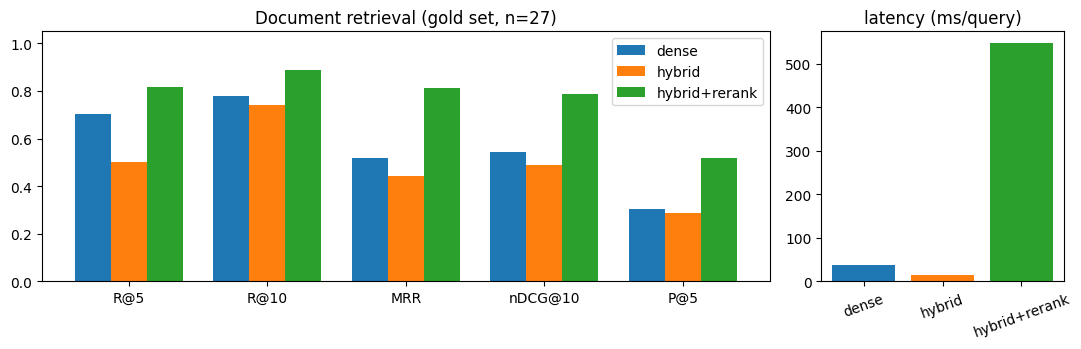

In [17]:
GOLD = json.loads((NB / "eval_qa.json").read_text(encoding="utf-8"))["questions"]
ANSWERABLE = [q for q in GOLD if q["answerable"]]
UNANSWERABLE = [q for q in GOLD if not q["answerable"]]
print(f"doc gold set: {len(ANSWERABLE)} answerable + {len(UNANSWERABLE)} unanswerable")


def eval_retrieval(mode, rerank):
    rows = []
    for q in ANSWERABLE:
        gold = set(q["gold_docs"])
        t0 = time.perf_counter()
        _, order = retrieve(q["question"], k=10, mode=mode, rerank=rerank)
        dt = time.perf_counter() - t0
        rel = np.array([doc_of_chunk[i] in gold for i in order])
        first = int(np.argmax(rel)) if rel.any() else None
        seen, gains = set(), []
        for i in order[:10]:
            d = doc_of_chunk[i]
            gains.append(1.0 if (d in gold and d not in seen) else 0.0)
            seen.add(d)
        idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(gold), 10)))
        rows.append(
            {
                "id": q["id"],
                "format": q["format"],
                "R@5": len(gold & set(doc_of_chunk[order[:5]])) / len(gold),
                "R@10": len(gold & set(doc_of_chunk[order[:10]])) / len(gold),
                "MRR": 0.0 if first is None else 1.0 / (first + 1),
                "nDCG@10": sum(g / math.log2(i + 2) for i, g in enumerate(gains))
                / idcg,
                "P@5": float(rel[:5].mean()),
                "ms": dt * 1e3,
            }
        )
    return pd.DataFrame(rows)


RET_CONFIGS = {
    "dense": ("dense", False),
    "hybrid": ("hybrid", False),
    "hybrid+rerank": ("hybrid", True),
}
retrieve("consulta de calentamiento sobre MAVIS", k=3, rerank=True)  # warm encoders
ret_per_q = {}
for name, (mode, rr) in RET_CONFIGS.items():
    t0 = time.time()
    ret_per_q[name] = eval_retrieval(mode, rr)
    print(f"  {name:14s} done in {time.time()-t0:.1f}s", flush=True)

RET_TABLE = pd.DataFrame(
    {
        n: df[["R@5", "R@10", "MRR", "nDCG@10", "P@5", "ms"]].mean()
        for n, df in ret_per_q.items()
    }
).T
RET_TABLE[["R@5", "R@10", "MRR", "nDCG@10", "P@5"]] = RET_TABLE[
    ["R@5", "R@10", "MRR", "nDCG@10", "P@5"]
].round(3)
RET_TABLE["ms"] = RET_TABLE["ms"].round(0)
print("\n=== Document retrieval (27 queries, doc-level relevance) ===")
display(RET_TABLE)
per_fmt_mrr = pd.DataFrame(
    {n: df.groupby("format")["MRR"].mean() for n, df in ret_per_q.items()}
).round(3)
per_fmt_mrr["n"] = ret_per_q["hybrid"].groupby("format").size()
print("=== MRR by primary gold format ===")
display(per_fmt_mrr)
(CACHE / "retrieval_eval.json").write_text(
    json.dumps(
        {"table": RET_TABLE.to_dict(), "per_format_mrr": per_fmt_mrr.to_dict()},
        indent=2,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [3, 1]})
metrics = ["R@5", "R@10", "MRR", "nDCG@10", "P@5"]
x = np.arange(len(metrics))
w = 0.26
for j, name in enumerate(RET_CONFIGS):
    axes[0].bar(x + (j - 1) * w, RET_TABLE.loc[name, metrics], w, label=name)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].set_title("Document retrieval (gold set, n=27)")
axes[1].bar(range(3), RET_TABLE["ms"], color=["C0", "C1", "C2"])
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(RET_CONFIGS, rotation=20)
axes[1].set_title("latency (ms/query)")
plt.tight_layout()
plt.savefig(FIGS / "retrieval_metrics.png", dpi=130)
plt.show()

## 14 · Evaluation III, answer quality

End-to-end measurement on five complementary axes (no single metric is trustworthy
alone, together they triangulate):

| metric | type | catches |
|---|---|---|
| **token-F1** vs reference | deterministic | gross lexical correctness (punishes EN→ES paraphrase, read as a *floor*) |
| **correctness (1-5)** | LLM-judge vs reference | semantic correctness and completeness |
| **faithfulness (1-5)** | LLM-judge vs retrieved context | hallucination |
| **citation validity** | deterministic | every `[n]` points to an existing block |
| **abstention accuracy** | LLM-judge, 4 unanswerable questions | saying "the docs don't cover this" instead of inventing |

Configurations: **base** (hybrid) vs **improved** (hybrid + re-rank), latency included.
Context now includes the [V] video block, so cache keys carry a context version.
Caveats: judge = answer model unless `RAG_JUDGE_MODEL` says otherwise; n=31 questions
gives indicative numbers only.

In [18]:
def _norm_tokens(s):
    s = unicodedata.normalize("NFKD", str(s).lower())
    s = "".join(c for c in s if not unicodedata.combining(c))
    return re.findall(r"[a-z0-9]+", s)


def token_f1(candidate, reference):
    c, r = Counter(_norm_tokens(candidate)), Counter(_norm_tokens(reference))
    common = sum((c & r).values())
    if not common:
        return 0.0
    p, rec = common / max(sum(c.values()), 1), common / max(sum(r.values()), 1)
    return 2 * p * rec / (p + rec)


def _judge_json(system, user, retries=2):
    for _ in range(retries + 1):
        txt = _chat(JUDGE_MODEL, system, user, max_tokens=200)
        m = re.search(r"\{.*?\}", txt, re.S)
        if m:
            try:
                return json.loads(m.group(0))
            except json.JSONDecodeError:
                continue
    return None


J_CORRECT = (
    "You evaluate a candidate answer against a reference answer for a given question. "
    "Score 5 = factually correct and complete; 3 = partially correct or incomplete; "
    "1 = wrong or contradicts the reference. Ignore wording/language differences and "
    'bracketed citations. Reply ONLY with JSON: {"score": <1-5>}'
)
J_FAITH = (
    "You check whether an answer is fully supported by the given context blocks. "
    "Score 5 = every factual claim appears in the context; 3 = mostly supported with "
    "minor unsupported details; 1 = mostly unsupported/invented. An explicit statement "
    "that the documentation does not cover the question counts as supported. "
    'Reply ONLY with JSON: {"score": <1-5>}'
)
J_ABSTAIN = (
    "You check whether an answer states that the requested information is NOT available "
    "in the documentation/context (an abstention). Reply ONLY with JSON: "
    '{"abstained": true|false}'
)


def cite_stats(answer, k=TOPK_CONTEXT):
    nums = {int(x) for x in re.findall(r"\[(\d{1,2})\]", answer)}
    return bool(nums), bool(nums) and max(nums) <= k and min(nums) >= 1

In [19]:
GEN_CACHE = CACHE / "gen_results.json"
try:
    store = json.loads(GEN_CACHE.read_text()) if GEN_CACHE.exists() else {}
except (json.JSONDecodeError, OSError) as e:
    print(f"gen-results cache UNREADABLE ({e!r}) -> starting fresh")
    store = {}
CTX_VER = "ctx2"  # context now includes the [V] video block
GEN_CONFIGS = {
    "base (hybrid)": dict(mode="hybrid", rerank=False),
    "improved (+rerank)": dict(mode="hybrid", rerank=True),
}


def _key(cfg, qid):
    return f"{CHAT_MODEL}|{JUDGE_MODEL}|{CTX_VER}|{cfg}|{qid}"


if not LLM_OK:
    print("skipped (no LLM available); set OPENAI_API_KEY / .env and re-run from §10.")
else:
    todo = [(c, q) for c in GEN_CONFIGS for q in GOLD if _key(c, q["id"]) not in store]
    print(
        f"questions to run: {len(todo)} (cached: {len(GOLD) * len(GEN_CONFIGS) - len(todo)})"
    )
    t00 = time.time()
    for n, (cfg, q) in enumerate(todo, 1):
        out = rag_answer(q["question"], **GEN_CONFIGS[cfg])
        rec = {
            "answer": out["answer"],
            "t_retrieval": out["t_retrieval"],
            "t_generation": out["t_generation"],
        }
        rec["has_cite"], rec["cites_valid"] = cite_stats(out["answer"])
        if q["answerable"]:
            rec["f1"] = token_f1(out["answer"], q["reference_answer"])
            j = _judge_json(
                J_CORRECT,
                f"Question: {q['question']}\n\nReference answer: "
                f"{q['reference_answer']}\n\nCandidate answer: {out['answer']}",
            )
            rec["correctness"] = j.get("score") if j else None
            j = _judge_json(
                J_FAITH,
                "Context blocks:\n\n"
                + out["context"]
                + "\n\nAnswer to check:\n"
                + out["answer"],
            )
            rec["faithfulness"] = j.get("score") if j else None
        else:
            j = _judge_json(J_ABSTAIN, "Answer:\n" + out["answer"])
            rec["abstained"] = j.get("abstained") if j else None
        store[_key(cfg, q["id"])] = rec
        GEN_CACHE.write_text(json.dumps(store, ensure_ascii=False, indent=1))
        print(
            f"  [{n}/{len(todo)}] {cfg:18s} {q['id']}  ({time.time()-t00:.0f}s elapsed)",
            flush=True,
        )
    print("generation runs complete")

questions to run: 62 (cached: 0)
  [1/62] base (hybrid)      q01  (13s elapsed)
  [2/62] base (hybrid)      q02  (31s elapsed)
  [3/62] base (hybrid)      q03  (55s elapsed)
  [4/62] base (hybrid)      q04  (73s elapsed)
  [5/62] base (hybrid)      q05  (81s elapsed)
  [6/62] base (hybrid)      q06  (98s elapsed)
  [7/62] base (hybrid)      q07  (116s elapsed)
  [8/62] base (hybrid)      q08  (141s elapsed)
  [9/62] base (hybrid)      q09  (154s elapsed)
  [10/62] base (hybrid)      q10  (166s elapsed)
  [11/62] base (hybrid)      q11  (182s elapsed)
  [12/62] base (hybrid)      q12  (200s elapsed)
  [13/62] base (hybrid)      q13  (212s elapsed)
  [14/62] base (hybrid)      q14  (231s elapsed)
  [15/62] base (hybrid)      q15  (246s elapsed)
  [16/62] base (hybrid)      q16  (278s elapsed)
  [17/62] base (hybrid)      q17  (298s elapsed)
  [18/62] base (hybrid)      q18  (310s elapsed)
  [19/62] base (hybrid)      q19  (323s elapsed)
  [20/62] base (hybrid)      q20  (337s elapsed)
  

=== Answer quality; 27 answerable + 4 unanswerable ===
    (chat=gpt-5-mini, judge=gpt-5-mini, context=ctx2)


,token-F1,correctness (1-5),faithfulness (1-5),citations valid,abstention acc,latency (s)
config,,,,,,
base (hybrid),0.304,2.778,4.630,1.0,1.0,8.302
improved (+rerank),0.388,4.111,4.926,1.0,1.0,9.797


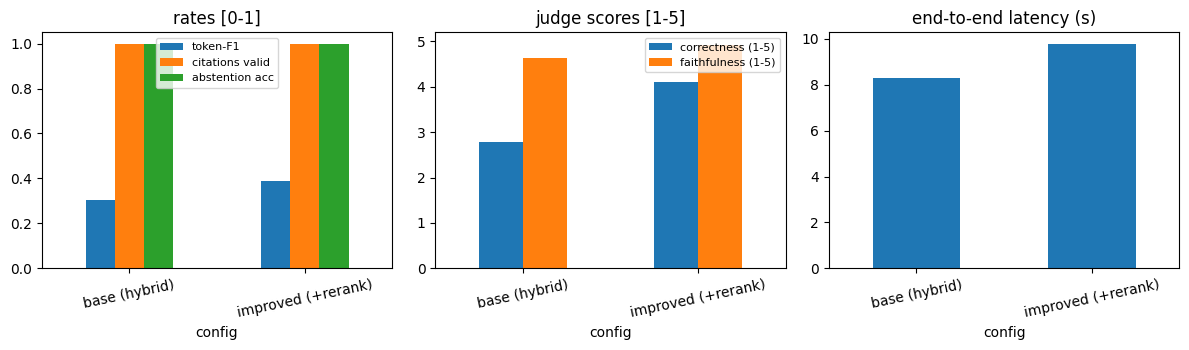


--- hardest question for the improved config: q11 (correctness 1) ---
Q: ¿Qué métricas obtuvo la búsqueda híbrida frente a la densa en el gold set del buscador de vídeos?
A: La documentación de MAVIS no cubre qué métricas obtuvo la búsqueda híbrida frente a la densa en el gold set del buscador de vídeos [1].  
El gold set mencionado consiste en 16 consultas de nicho anotadas a mano (`eval_queries.json`) que sirven de referencia para la evaluación [1].


In [20]:
if LLM_OK:
    rows = []
    for cfg in GEN_CONFIGS:
        recs = {q["id"]: store.get(_key(cfg, q["id"])) for q in GOLD}
        a = [recs[q["id"]] for q in ANSWERABLE if recs[q["id"]]]
        u = [recs[q["id"]] for q in UNANSWERABLE if recs[q["id"]]]
        rows.append(
            {
                "config": cfg,
                "token-F1": np.mean([r["f1"] for r in a]),
                "correctness (1-5)": np.mean(
                    [r["correctness"] for r in a if r["correctness"]]
                ),
                "faithfulness (1-5)": np.mean(
                    [r["faithfulness"] for r in a if r["faithfulness"]]
                ),
                "citations valid": np.mean([r["cites_valid"] for r in a]),
                "abstention acc": np.mean([bool(r["abstained"]) for r in u])
                if u
                else np.nan,
                "latency (s)": np.mean(
                    [r["t_retrieval"] + r["t_generation"] for r in a]
                ),
            }
        )
    GEN_TABLE = pd.DataFrame(rows).set_index("config").round(3)
    print(
        f"=== Answer quality; {len(ANSWERABLE)} answerable + {len(UNANSWERABLE)} unanswerable ==="
    )
    print(f"    (chat={CHAT_MODEL}, judge={JUDGE_MODEL}, context={CTX_VER})")
    display(GEN_TABLE)
    (CACHE / "generation_eval.json").write_text(GEN_TABLE.to_json(indent=2))

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    GEN_TABLE[["token-F1", "citations valid", "abstention acc"]].plot.bar(
        ax=axes[0], rot=12
    )
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title("rates [0-1]")
    axes[0].legend(fontsize=8)
    GEN_TABLE[["correctness (1-5)", "faithfulness (1-5)"]].plot.bar(ax=axes[1], rot=12)
    axes[1].set_ylim(0, 5.2)
    axes[1].set_title("judge scores [1-5]")
    axes[1].legend(fontsize=8)
    GEN_TABLE[["latency (s)"]].plot.bar(ax=axes[2], rot=12, legend=False)
    axes[2].set_title("end-to-end latency (s)")
    plt.tight_layout()
    plt.savefig(FIGS / "generation_metrics.png", dpi=130)
    plt.show()

    worst = min(
        ((q, store[_key("improved (+rerank)", q["id"])]) for q in ANSWERABLE),
        key=lambda t: t[1].get("correctness") or 9,
    )
    print(
        f"\n--- hardest question for the improved config: {worst[0]['id']} "
        f"(correctness {worst[1].get('correctness')}) ---"
    )
    print("Q:", worst[0]["question"])
    print("A:", worst[1]["answer"][:600])
else:
    print("skipped (no LLM)")

## 15 · Summary

- **The core is multimodal**: a self-contained video index (300 thumbnails + titles)
  searchable by text or by image through SigLIP (image, cross-modal), mpnet (titles)
  and BM25, fused with RRF; §12 measures it with a hand-annotated gold set and a
  label-free cross-modal alignment check.
- **The document layer is generic**: every supported file found under `corpus/` is
  ingested by extension (structured formats serialized into sentences), chunked with
  provenance headers, and served by the hybrid dense+lexical engine; phase 2 re-ranks
  with a cross-encoder, and §13 quantifies each configuration.
- **Generation is text-only with visual evidence**: the LLM (OpenAI-compatible) sees
  document blocks plus a [V] block of related video titles, cites everything inline,
  and abstains explicitly; the retrieved thumbnails are displayed to the user. §14
  measures answers on five axes for phase 1 vs phase 2.
- **Self-contained**: every indexed byte lives inside `04-multimodal-rag/`; caches are
  local and regenerable from the local corpus.

**Limitations**: gold sets are small and single-annotator (indicative only); judge =
answer model unless overridden; doc-level relevance is coarse; PDFs enter as raw page
text; token-F1 punishes cross-lingual paraphrase; 300 videos is a deliberately small,
shippable sample of the 42k-video MAVIS corpus.